<div style="text-align:center">

# Proyecto 1  
## Clasificación de Riesgo Crediticio  

**Machine Learning**  
Universidad del Rosario

Vanessa Ochoa, Nilson Amaya, Juan Zamora

</div>


---

## Tabla de contenido

- [Introducción](#1-introducción)
- [Importación del dataset](#2-importación-del-dataset)
- [EDA](#3-análisis-exploratorio-de-datos-eda)
- [Modelos](#4-modelos)
- [Optimización de hiperparámetros y validación](#5-resultados)
- [Métricas de evaluación, ROC y decisión de umbral](#6-conclusiones)
- [Predicción en el conjunto de test](#7-test)
- [Diagrama del pipeline](#8-diagrama)

<a id="1-introducción"></a>
## 1. Introducción

El riesgo crediticio es uno de los principales problemas que enfrentan las instituciones financieras, ya que implica la posibilidad de que una persona no cumpla con sus obligaciones de pago. Poder anticipar este tipo de situaciones es clave para reducir pérdidas y mejorar la toma de decisiones.

En este proyecto se utiliza el dataset **"Give Me Some Credit"** con el objetivo de predecir si una persona tendrá dificultades financieras en los próximos dos años. Este problema se aborda como una tarea de **clasificación binaria**, donde el modelo debe identificar si un cliente presenta riesgo de incumplimiento o no.

Para resolver este problema se desarrolla un flujo completo de **Machine Learning**, que incluye análisis exploratorio de datos (EDA), tratamiento de valores faltantes y outliers, implementación de modelos de clasificación como **k-NN** y **Regresión Logística**, así como la optimización de hiperparámetros mediante **Grid Search** y validación cruzada.

Finalmente, se comparan los modelos obtenidos para identificar cuál ofrece el mejor desempeño en la predicción del riesgo crediticio.

<a id="2-importación-del-dataset"></a>
## 2. Importación del dataset

Antes de cargar el dataset, se importan las librerías necesarias para realizar el proyecto.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [2]:
# Cargamos el dataset

train = pd.read_csv("../input/cs-training.csv")
test = pd.read_csv("../input/cs-test.csv")
train = train.drop(columns=['Unnamed: 0'])
test = test.drop(columns=['Unnamed: 0'])

# ver primeras filas
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: float64(

### 2.1 Descripción de las variables

- **SeriousDlqin2yrs:** Indica si la persona ha tenido una morosidad grave, es decir, un atraso de 90 días o más en el pago de sus obligaciones durante los últimos dos años. Es la variable objetivo del modelo.

- **RevolvingUtilizationOfUnsecuredLines:** Proporción del saldo utilizado en tarjetas de crédito y líneas de crédito personales respecto al límite total disponible.

- **age:** Edad del solicitante del crédito expresada en años.

- **NumberOfTime30-59DaysPastDueNotWorse:** Número de veces que el prestatario ha tenido retrasos en sus pagos entre 30 y 59 días durante los últimos dos años.

- **DebtRatio:** Relación entre las obligaciones financieras mensuales (deudas, manutención, gastos) y el ingreso bruto mensual del prestatario.

- **MonthlyIncome:** Ingreso mensual reportado por el prestatario.

- **NumberOfOpenCreditLinesAndLoans:** Número total de préstamos y líneas de crédito abiertas, como tarjetas de crédito, préstamos de auto o hipotecas.

- **NumberOfTimes90DaysLate:** Número de veces que el prestatario ha tenido retrasos en pagos de 90 días o más.

- **NumberRealEstateLoansOrLines:** Número de préstamos relacionados con bienes raíces, incluyendo hipotecas y líneas de crédito sobre vivienda.

- **NumberOfTime60-89DaysPastDueNotWorse:** Número de veces que el prestatario ha tenido retrasos en pagos entre 60 y 89 días en los últimos dos años.

- **NumberOfDependents:** Número de personas dependientes económicamente del prestatario, como hijos o cónyuge.

In [3]:
train.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


<a id="3-análisis-exploratorio-de-datos-eda"></a>
## 3. Análisis Exploratorio de Datos (EDA)

### 3.1 Identificación y tratamiento de datos faltantes e imputación lógica

Primero identificamos el porcentaje de datos faltantes por variable y, con base en el contexto, aplicamos una imputación lógica:




In [4]:
faltantes = train.isnull().sum()
porcentaje = (faltantes / len(train)) * 100
tabla_faltantes = pd.DataFrame({
    'Valores faltantes': faltantes,
    'Porcentaje %': porcentaje.round(2)
})
print(tabla_faltantes[tabla_faltantes['Valores faltantes'] > 0])

                    Valores faltantes  Porcentaje %
MonthlyIncome                   29731         19.82
NumberOfDependents               3924          2.62


Con base en la revisión de valores faltantes, se identificó que las variables MonthlyIncome y NumberOfDependents presentan datos ausentes. Dado que ambas corresponden a variables numéricas, se optó por realizar una imputación utilizando la mediana de cada variable. La mediana se define como el valor central de la distribución cuando los datos se ordenan de menor a mayor. A diferencia de la media, la mediana es menos sensible a la presencia de outliers que en variables financieras es muy común que pase. Por esta razón, la mediana permite imputar los valores faltantes con un valor representativo de la distribución sin distorsionar significativamente su forma. De esta manera, se conserva la estructura general de los datos y se evita introducir sesgos que podrían afectar el entrenamiento del modelo.

In [5]:
# Imputación lógica con medianas del train
median_monthly_income = train['MonthlyIncome'].median()
median_dependents = train['NumberOfDependents'].median()

train['MonthlyIncome'] = train['MonthlyIncome'].fillna(median_monthly_income)
train['NumberOfDependents'] = train['NumberOfDependents'].fillna(median_dependents)

# Verificar que ya no hay faltantes
print("Faltantes después de imputación:")
print(train.isnull().sum().sum())
print(f"Mediana MonthlyIncome (train): {median_monthly_income:.2f}")
print(f"Mediana NumberOfDependents (train): {median_dependents:.2f}")


Faltantes después de imputación:
0
Mediana MonthlyIncome (train): 5400.00
Mediana NumberOfDependents (train): 0.00


### 3.2 Análisis de distribuciones y detección de outliers

Analizamos la forma de las distribuciones con histogramas y boxplots. Para detectar valores atípicos extremos usamos el criterio del **IQR (rango intercuartílico)** y realizamos winsorización suave (capado por percentiles) en variables con colas muy largas.


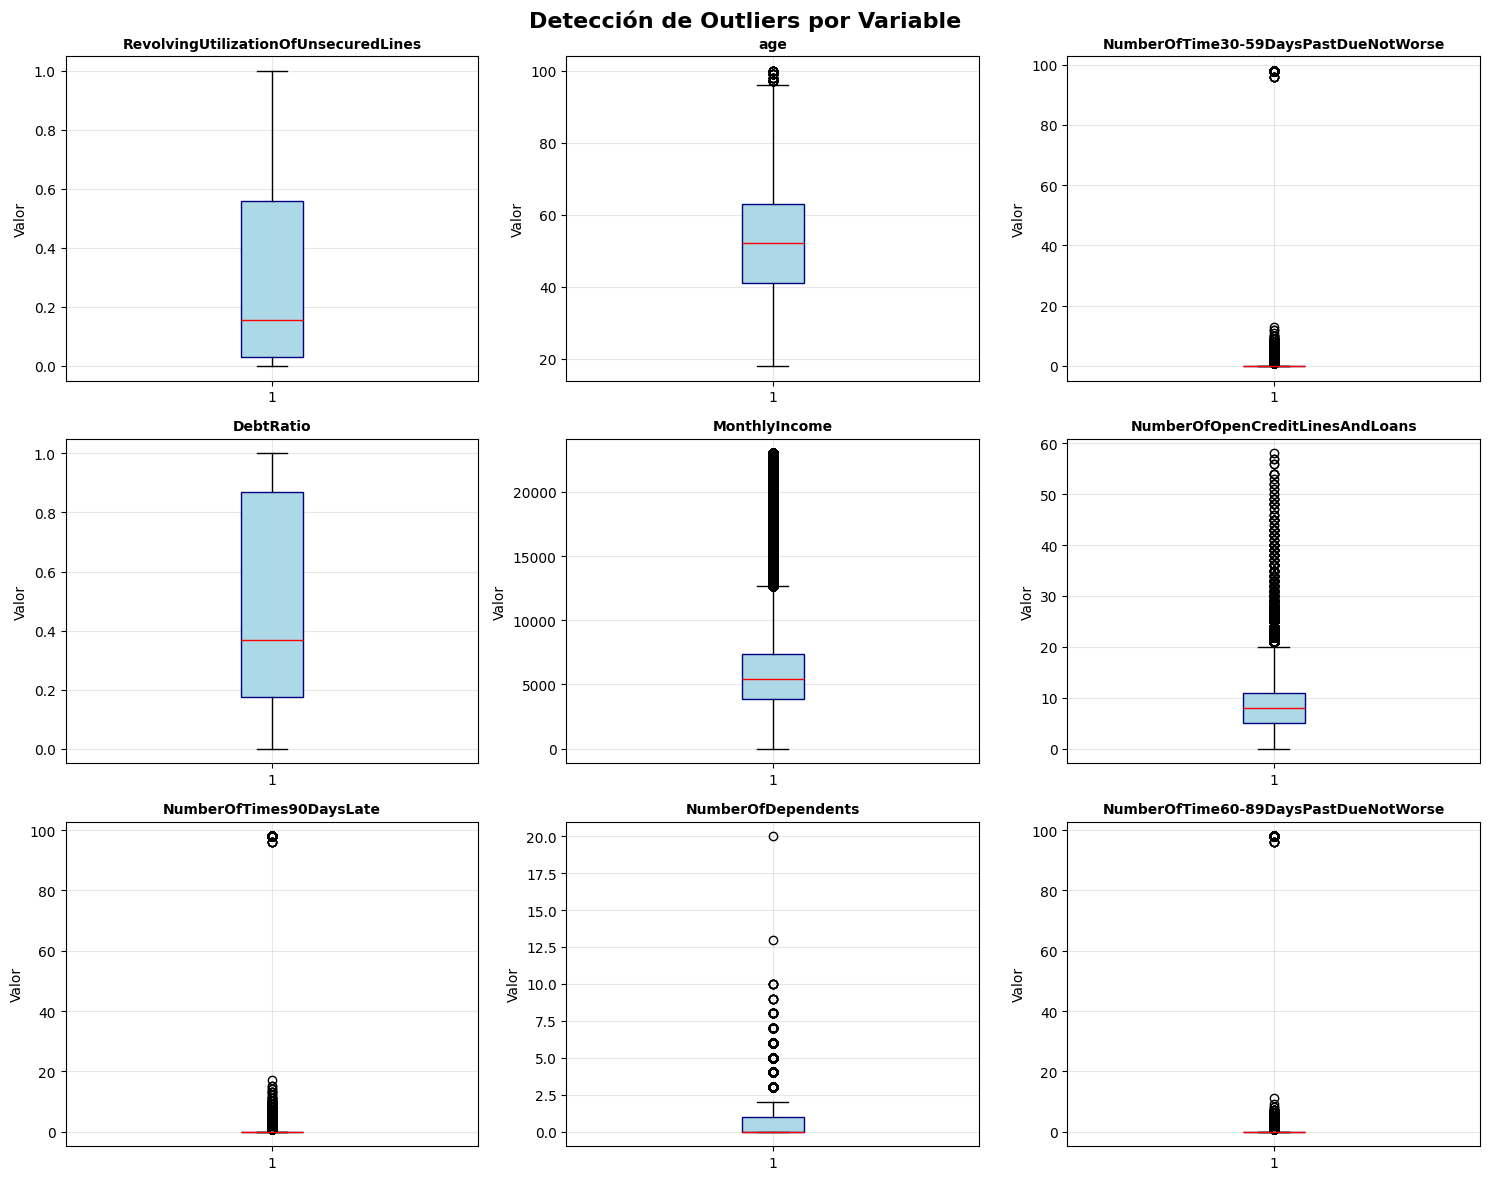

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

columnas = [
    'RevolvingUtilizationOfUnsecuredLines', 'age',
    'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio',
    'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans',
    'NumberOfTimes90DaysLate', 'NumberOfDependents',
    'NumberOfTime60-89DaysPastDueNotWorse'
]

for i, col in enumerate(columnas):
    axes[i].boxplot(train[col], patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='navy'),
                    medianprops=dict(color='red'))
    
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Valor')
    axes[i].grid(alpha=0.3)

fig.suptitle('Detección de Outliers por Variable',
             fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

A partir de los boxplots se observa que varias variables presentan valores atípicos, especialmente en RevolvingUtilizationOfUnsecuredLines, DebtRatio y MonthlyIncome, donde hay una gran dispersión y algunos valores extremadamente altos. En las variables relacionadas con retrasos en pagos, la mayoría de los valores se concentran cerca de cero, pero aparecen algunos casos con muchos incumplimientos.

In [12]:
# Tratamiento de valores extremos

# RevolvingUtilization y DebtRatio como proporciones entre 0 y 1
train['RevolvingUtilizationOfUnsecuredLines'] = train['RevolvingUtilizationOfUnsecuredLines'].clip(0, 1)
train['DebtRatio'] = train['DebtRatio'].clip(0, 1)

# Age en un rango razonable
train['age'] = train['age'].clip(18, 100)

# MonthlyIncome: recorte en percentil 99 para reducir el efecto de outliers
cap_income = train['MonthlyIncome'].quantile(0.99)
train['MonthlyIncome'] = train['MonthlyIncome'].clip(0, cap_income)

print("Outliers tratados en variables continuas")
print("\nEstadísticas después del tratamiento:")
train.describe().round(2)

Outliers tratados en variables continuas

Estadísticas después del tratamiento:


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00
mean,0.07,0.32,52.30,0.42,0.47,6142.45,8.45,0.27,1.02,0.24,0.74
std,0.25,0.35,14.77,4.19,0.36,3835.68,5.15,4.17,1.13,4.16,1.11
min,0.00,0.00,18.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.03,41.00,0.00,0.18,3903.00,5.00,0.00,0.00,0.00,0.00
50%,0.00,0.15,52.00,0.00,0.37,5400.00,8.00,0.00,1.00,0.00,0.00
75%,0.00,0.56,63.00,0.00,0.87,7400.00,11.00,0.00,2.00,0.00,1.00
max,1.00,1.00,100.00,98.00,1.00,23000.00,58.00,98.00,54.00,98.00,20.00


El tratamiento de outliers se aplicó únicamente a variables continuas donde existían valores claramente extremos o inconsistentes. Las variables de retrasos en pagos se mantuvieron sin modificación, ya que no se cuenta con evidencia suficiente para considerar algunos valores como errores de registro.

### 3.3 Análisis de correlación y selección de características justificadas

Calculamos la correlación de Pearson entre variables numéricas y observamos su relación con la variable objetivo (**SeriousDlqin2yrs**). 


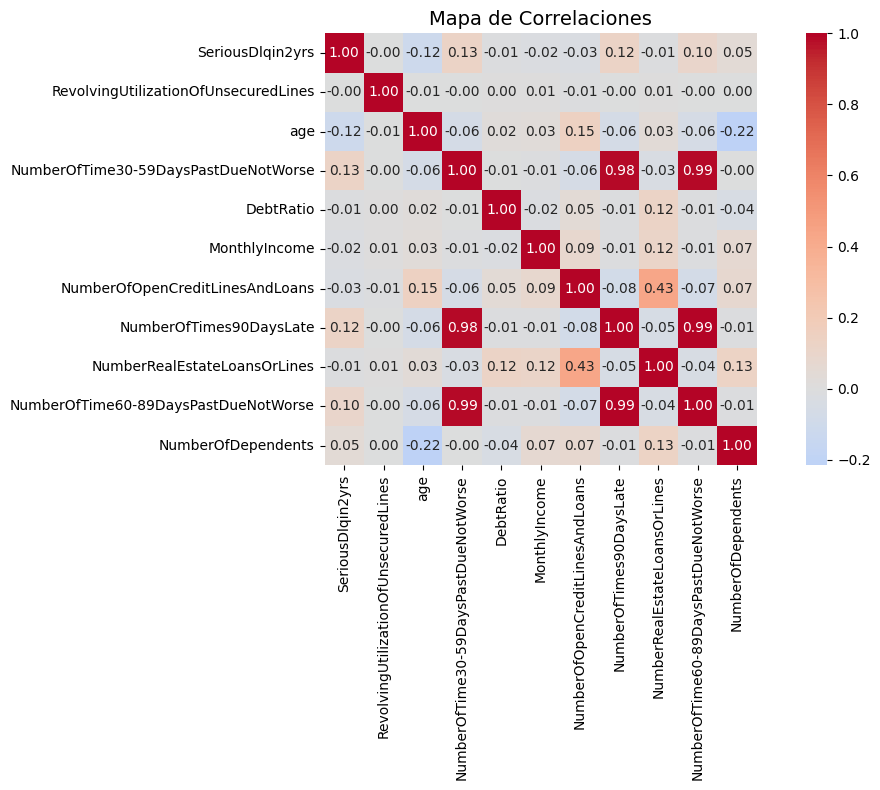


Correlación con SeriousDlqin2yrs:
SeriousDlqin2yrs                        1.000000
NumberOfTime30-59DaysPastDueNotWorse    0.125587
NumberOfTimes90DaysLate                 0.117175
NumberOfTime60-89DaysPastDueNotWorse    0.102261
NumberOfDependents                      0.046869
RevolvingUtilizationOfUnsecuredLines   -0.001802
NumberRealEstateLoansOrLines           -0.007038
DebtRatio                              -0.007602
MonthlyIncome                          -0.017151
NumberOfOpenCreditLinesAndLoans        -0.029669
age                                    -0.115386
Name: SeriousDlqin2yrs, dtype: float64


In [6]:
# Mapa de calor de correlaciones
plt.figure(figsize=(12, 8))
correlaciones = train.corr()

sns.heatmap(correlaciones,
            annot=True,      # muestra los números
            fmt='.2f',       # 2 decimales
            cmap='coolwarm', # azul=negativo, rojo=positivo
            center=0,
            square=True)

plt.title('Mapa de Correlaciones', fontsize=14)
plt.tight_layout()
plt.show()

# Correlaciones con la variable objetivo
print("\nCorrelación con SeriousDlqin2yrs:")
print(correlaciones['SeriousDlqin2yrs'].sort_values(ascending=False))

Para el análisis se utilizaron únicamente las variables con mayor relación con el incumplimiento (SeriousDlqin2yrs). Dado que las variables de retrasos en pagos presentan correlaciones muy altas entre sí, se decidió no considerar NumberOfTime60-89DaysPastDueNotWorse para evitar redundancia y posibles problemas de multicolinealidad.

In [7]:
# Selección justificada de características
variables = [
    'RevolvingUtilizationOfUnsecuredLines',
    'age',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
    'DebtRatio',
    'MonthlyIncome',
    'NumberOfOpenCreditLinesAndLoans',
    'NumberRealEstateLoansOrLines',
    'NumberOfDependents'
]

X = train[variables]
y = train['SeriousDlqin2yrs']

print('Variables seleccionadas para modelado:')
print(variables)
print('\nDimensiones de X e y:', X.shape, y.shape)


Variables seleccionadas para modelado:
['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines', 'NumberOfDependents']

Dimensiones de X e y: (150000, 9) (150000,)


<a id="4-modelos"></a>
## 4. Implementación de Modelos

### 4.1 Preparación de datos para modelado y validación
Se divide el conjunto de entrenamiento en entrenamiento interno y validación. Además, se aplica al set de `test` la misma lógica de imputación y tratamiento de variables continuas usando parámetros obtenidos en train.

In [15]:
# Variables predictoras y objetivo
X = train[variables].copy()
y = train['SeriousDlqin2yrs'].copy()

# Split interno para comparar modelos
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2
)

# Preparación del conjunto test
X_test = test[variables].copy()

X_test['MonthlyIncome'] = X_test['MonthlyIncome'].fillna(median_monthly_income)
X_test['NumberOfDependents'] = X_test['NumberOfDependents'].fillna(median_dependents)

# Mismo tratamiento de continuas realizado en train
for df in [X_test]:
    df['RevolvingUtilizationOfUnsecuredLines'] = df['RevolvingUtilizationOfUnsecuredLines'].clip(0, 1)
    df['DebtRatio'] = df['DebtRatio'].clip(0, 1)
    df['age'] = df['age'].clip(18, 100)
    df['MonthlyIncome'] = df['MonthlyIncome'].clip(0, cap_income)

print('Dimensiones split interno:')
print('X_train:', X_train.shape, '| X_val:', X_val.shape)

print('\nFaltantes:')
print('X_val:', X_val.isnull().sum().sum())
print('X_test:', X_test.isnull().sum().sum())

Dimensiones split interno:
X_train: (120000, 9) | X_val: (30000, 9)

Faltantes:
X_val: 0
X_test: 0


### 4.2 k-Vecinos más cercanos

In [16]:
resultados_modelos = []

# -----------------------------
# k-NN con Escalamiento  (Min-Max)
# -----------------------------
scaler_minmax = MinMaxScaler()

X_train_minmax = scaler_minmax.fit_transform(X_train)
X_val_minmax = scaler_minmax.transform(X_val)

knn_minmax = KNeighborsClassifier(n_neighbors=5)
knn_minmax.fit(X_train_minmax, y_train)

pred_knn_minmax = knn_minmax.predict(X_val_minmax)
proba_knn_minmax = knn_minmax.predict_proba(X_val_minmax)[:, 1]

auc_knn_minmax = roc_auc_score(y_val, proba_knn_minmax)

# Guardar resultados
resultados_modelos.append({
    "Modelo": "k-NN (MinMax Scaling)",
    "ROC-AUC": auc_knn_minmax
})

# Resultados en pantalla
print("\n===== k-NN con Normalización (MinMax) =====")
print(classification_report(y_val, pred_knn_minmax))

print("Matriz de confusión:")
print(confusion_matrix(y_val, pred_knn_minmax))

print(f"ROC-AUC: {auc_knn_minmax:.4f}")



===== k-NN con Normalización (MinMax) =====
              precision    recall  f1-score   support

           0       0.94      0.99      0.96     27993
           1       0.36      0.08      0.13      2007

    accuracy                           0.93     30000
   macro avg       0.65      0.53      0.54     30000
weighted avg       0.90      0.93      0.91     30000

Matriz de confusión:
[[27716   277]
 [ 1853   154]]
ROC-AUC: 0.6602


In [17]:
# -----------------------------
# k-NN con Estandarización (media y desviación estándar)
# -----------------------------
scaler_std = StandardScaler()

X_train_std = scaler_std.fit_transform(X_train)
X_val_std = scaler_std.transform(X_val)

knn_std = KNeighborsClassifier(n_neighbors=5)
knn_std.fit(X_train_std, y_train)

pred_knn_std = knn_std.predict(X_val_std)
proba_knn_std = knn_std.predict_proba(X_val_std)[:, 1]

auc_knn_std = roc_auc_score(y_val, proba_knn_std)

# Guardar resultados
resultados_modelos.append({
    "Modelo": "k-NN (Standard Scaling)",
    "ROC-AUC": auc_knn_std
})

# Resultados en pantalla
print("\n===== k-NN con Estandarización (StandardScaler) =====")
print(classification_report(y_val, pred_knn_std))

print("Matriz de confusión:")
print(confusion_matrix(y_val, pred_knn_std))

print(f"ROC-AUC: {auc_knn_std:.4f}")


===== k-NN con Estandarización (StandardScaler) =====
              precision    recall  f1-score   support

           0       0.94      0.99      0.96     27993
           1       0.46      0.12      0.19      2007

    accuracy                           0.93     30000
   macro avg       0.70      0.56      0.58     30000
weighted avg       0.91      0.93      0.91     30000

Matriz de confusión:
[[27709   284]
 [ 1765   242]]
ROC-AUC: 0.6904


### 4.3 Regresión Logística 

In [19]:
# -----------------------------
# Regresión Logística con Estandarización (media y desviación estándar)
# -----------------------------

log_reg = LogisticRegression(max_iter=50000, random_state=123)
log_reg.fit(X_train_std, y_train)

pred_log = log_reg.predict(X_val_std)
proba_log = log_reg.predict_proba(X_val_std)[:, 1]
auc_log = roc_auc_score(y_val, proba_log)

resultados_modelos.append({
    'Modelo': 'Regresión Logística con Estandarización',
    'ROC-AUC': auc_log
})

print('Regresión Logística con Estandarización')
print(classification_report(y_val, pred_log))
print('Matriz de confusión:\n', confusion_matrix(y_val, pred_log))
print(f'ROC-AUC: {auc_log:.4f}')


Regresión Logística con Estandarización
              precision    recall  f1-score   support

           0       0.93      1.00      0.97     27993
           1       0.45      0.01      0.02      2007

    accuracy                           0.93     30000
   macro avg       0.69      0.50      0.49     30000
weighted avg       0.90      0.93      0.90     30000

Matriz de confusión:
 [[27966    27]
 [ 1985    22]]
ROC-AUC: 0.8025


In [20]:
# -----------------------------
# Regresión Logística con Escalamiento  (Min-Max)
# -----------------------------

log_reg = LogisticRegression(max_iter=50000, random_state=123)
log_reg.fit(X_train_minmax, y_train)

pred_log_minmax = log_reg.predict(X_val_minmax)
proba_log_minmax = log_reg.predict_proba(X_val_minmax)[:, 1]
auc_log_minmax = roc_auc_score(y_val, proba_log_minmax)

resultados_modelos.append({
    'Modelo': 'Regresión Logística con Escalamiento (Min-Max)',
    'ROC-AUC': auc_log_minmax
})

print('Regresión Logística con Escalamiento (Min-Max)')
print(classification_report(y_val, pred_log_minmax))
print('Matriz de confusión:\n', confusion_matrix(y_val, pred_log_minmax))
print(f'ROC-AUC: {auc_log_minmax:.4f}')


Regresión Logística con Escalamiento (Min-Max)
              precision    recall  f1-score   support

           0       0.93      1.00      0.97     27993
           1       0.45      0.01      0.02      2007

    accuracy                           0.93     30000
   macro avg       0.69      0.50      0.49     30000
weighted avg       0.90      0.93      0.90     30000

Matriz de confusión:
 [[27966    27]
 [ 1985    22]]
ROC-AUC: 0.8013


In [21]:
tabla_resultados = pd.DataFrame(resultados_modelos).sort_values('ROC-AUC', ascending=False)
print('Comparación inicial de modelos (validación):')
print(tabla_resultados)

Comparación inicial de modelos (validación):
                                           Modelo   ROC-AUC
2         Regresión Logística con Estandarización  0.802463
3  Regresión Logística con Escalamiento (Min-Max)  0.801265
1                         k-NN (Standard Scaling)  0.690378
0                           k-NN (MinMax Scaling)  0.660195


<a id="5-resultados"></a>
## 5. Optimización de Hiperparámetros y Validación

En esta sección utilizamos **validación cruzada estratificada (StratifiedKFold)** y **Grid Search (GridSearchCV)** para buscar los mejores hiperparámetros de los modelos k-NN y Regresión Logística, usando como métrica principal el **ROC-AUC** debido al desbalance de clases.

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline

# Estrategia de validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

# Pipeline para k-NN con escalado
pipe_knn = Pipeline([
    ("scaler", StandardScaler()),  # el tipo de escalador se ajustará vía grilla
    ("knn", KNeighborsClassifier())
])

param_grid_knn = {
    "scaler": [StandardScaler(), MinMaxScaler()],
    "knn__n_neighbors": [5, 10, 20],
    "knn__weights": ["uniform", "distance"],
}

grid_knn = GridSearchCV(
    estimator=pipe_knn,
    param_grid=param_grid_knn,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=0,
)

# Ajuste de Grid Search para k-NN sobre todo el conjunto de entrenamiento
grid_knn.fit(X, y)

print("Mejores hiperparámetros k-NN:")
print(grid_knn.best_params_)
print(f"Mejor ROC-AUC medio (CV): {grid_knn.best_score_:.4f}")

# Tabla resumida de los mejores resultados de k-NN
resultados_knn_cv = (
    pd.DataFrame(grid_knn.cv_results_)
    .sort_values("mean_test_score", ascending=False)[
        ["params", "mean_test_score", "std_test_score"]
    ]
    .head(10)
)
resultados_knn_cv

### 5.1 Grid Search para Regresión Logística

A continuación optimizamos una **Regresión Logística** usando un `Pipeline` con `StandardScaler` y explorando distintos valores de `C` y del parámetro `class_weight`. Usamos nuevamente validación cruzada estratificada y **ROC-AUC** como métrica principal.

In [ ]:
# Grid Search para Regresión Logística con StandardScaler

pipe_log = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=50000, random_state=123))
])

param_grid_log = {
    "logreg__C": [0.1, 1.0, 10.0],
    "logreg__class_weight": [None, "balanced"],
}

grid_log = GridSearchCV(
    estimator=pipe_log,
    param_grid=param_grid_log,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=0,
)

grid_log.fit(X, y)

print("Mejores hiperparámetros Regresión Logística:")
print(grid_log.best_params_)
print(f"Mejor ROC-AUC medio (CV): {grid_log.best_score_:.4f}")

resultados_log_cv = (
    pd.DataFrame(grid_log.cv_results_)
    .sort_values("mean_test_score", ascending=False)[
        ["params", "mean_test_score", "std_test_score"]
    ]
    .head(10)
)
resultados_log_cv

### 5.2 Comparación de modelos tras validación cruzada

A partir de los resultados de `GridSearchCV`, comparamos los **mejores modelos** de k-NN y Regresión Logística según el ROC-AUC medio de validación cruzada. Esto nos permite elegir un **modelo final** para el resto del análisis.

In [ ]:
# Resumen comparativo de modelos después de Grid Search

mejor_auc_knn = grid_knn.best_score_
mejor_auc_log = grid_log.best_score_

resumen_modelos_cv = pd.DataFrame([
    {"Modelo": "k-NN (mejor configuración CV)", "ROC_AUC_CV": mejor_auc_knn},
    {"Modelo": "Regresión Logística (mejor configuración CV)", "ROC_AUC_CV": mejor_auc_log},
])

print("Comparación de modelos (ROC-AUC medio en CV):")
resumen_modelos_cv

<a id="6-conclusiones"></a>
## 6. Métricas de Evaluación y Decisión

En esta sección tomamos como **modelo final** la Regresión Logística con la mejor configuración encontrada en la sección 5 y:

- Evaluamos sus métricas en un conjunto de validación (accuracy, precision, recall, F1, matriz de confusión y ROC-AUC).
- Analizamos la **curva ROC**.
- Realizamos un **análisis de umbral** considerando distintos costos para Falsos Positivos (FP) y Falsos Negativos (FN), para proponer un umbral de decisión adecuado para riesgo crediticio.

### 6.1 Métricas del modelo final en el conjunto de validación

Usamos el split `X_train`, `X_val`, `y_train`, `y_val` definido anteriormente para evaluar el modelo de Regresión Logística con los mejores hiperparámetros obtenidos por Grid Search.

In [ ]:
# Ajuste del modelo final (Regresión Logística óptima) en el conjunto de entrenamiento interno

best_log_model = grid_log.best_estimator_

best_log_model.fit(X_train, y_train)

proba_val = best_log_model.predict_proba(X_val)[:, 1]
pred_val_05 = (proba_val >= 0.5).astype(int)

from sklearn.metrics import roc_curve, roc_auc_score

print("Métricas con umbral 0.5 (Regresión Logística óptima):")
print(classification_report(y_val, pred_val_05))
print("Matriz de confusión:\n", confusion_matrix(y_val, pred_val_05))
print(f"ROC-AUC (val): {roc_auc_score(y_val, proba_val):.4f}")

In [ ]:
# Curva ROC del modelo final

fpr, tpr, thresholds = roc_curve(y_val, proba_val)
auc_val = roc_auc_score(y_val, proba_val)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC (AUC = {auc_val:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.6)
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Curva ROC - Regresión Logística (validación)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

### 6.2 Análisis de umbral (threshold) basado en costo

En riesgo crediticio, típicamente un **Falso Negativo (FN)** (clasificar como “no riesgoso” a alguien que sí incumple) es más costoso que un **Falso Positivo (FP)** (clasificar como riesgoso a alguien que realmente pagaría). Para reflejar esto, definimos un esquema simple de costos:

- Costo(FN) = 5
- Costo(FP) = 1

Luego barrimos distintos umbrales \(t\) sobre la probabilidad estimada \(\hat{p}\) y calculamos el costo total \(5\cdot FN + 1\cdot FP\).

In [ ]:
# Barrido de umbrales con costos FN/FP

costo_FN = 5
costo_FP = 1

umbrales = np.linspace(0.05, 0.95, 19)

rows = []
for t in umbrales:
    pred_t = (proba_val >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, pred_t).ravel()

    precision_1 = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall_1 = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    costo_total = costo_FN * fn + costo_FP * fp

    rows.append({
        "umbral": float(t),
        "TP": int(tp),
        "FP": int(fp),
        "TN": int(tn),
        "FN": int(fn),
        "precision_clase1": precision_1,
        "recall_clase1": recall_1,
        "costo_total": int(costo_total),
    })

tabla_umbral = pd.DataFrame(rows).sort_values("costo_total")

print("Top 10 umbrales con menor costo total:")
tabla_umbral.head(10)

In [ ]:
# Visualización del costo total vs umbral

tabla_plot = pd.DataFrame(rows).sort_values("umbral")

best_row = tabla_plot.loc[tabla_plot["costo_total"].idxmin()]
best_t = best_row["umbral"]

plt.figure(figsize=(7, 4))
plt.plot(tabla_plot["umbral"], tabla_plot["costo_total"], marker="o")
plt.axvline(best_t, color="red", linestyle="--", alpha=0.7, label=f"Mejor umbral: {best_t:.2f}")
plt.xlabel("Umbral")
plt.ylabel("Costo total (5·FN + 1·FP)")
plt.title("Costo vs Umbral - Modelo final (validación)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print(f"Umbral recomendado (mínimo costo): {best_t:.2f}")
best_row

In [ ]:
# Métricas del modelo final con el umbral recomendado

pred_val_best = (proba_val >= best_t).astype(int)

print(f"Métricas con umbral recomendado t={best_t:.2f}:")
print(classification_report(y_val, pred_val_best))
print("Matriz de confusión:\n", confusion_matrix(y_val, pred_val_best))

<a id="7-test"></a>
## 7. Predicción en el conjunto de test

Entrenamos el **modelo final** (Regresión Logística con hiperparámetros óptimos) usando **todo el conjunto de entrenamiento** y generamos probabilidades para el conjunto `test`.

Finalmente, construimos un archivo tipo *submission* con el formato de `sampleEntry.csv` (`Id`, `Probability`).

In [ ]:
# Entrenar modelo final con todos los datos y predecir en test

modelo_final = grid_log.best_estimator_
modelo_final.fit(X, y)

proba_test = modelo_final.predict_proba(X_test)[:, 1]

# Construcción del DataFrame de envío
submission = pd.DataFrame({
    "Id": test.index + 1,
    "Probability": proba_test,
})

submission.head()

In [ ]:
# (Opcional) Guardar submission en disco

import os

os.makedirs("../output", exist_ok=True)
output_path = "../output/submission_logistic.csv"
submission.to_csv(output_path, index=False)
print(f"Archivo guardado en: {output_path}")